In [7]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Concatenate
from tensorflow.keras.models import Model
import pandas as pd
import numpy as np
import os
import glob
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [8]:

# ----------------------------
# Config
# ----------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-3
DROPOUT_RATE = 0.5
N_CLASSES = 3   # Normal, Benign, Malignant


In [9]:

# ----------------------------
# Load & Merge Metadata
# ----------------------------
excel_path = "CDD-CESM/Radiology-manual-annotations.xlsx"
sheets = pd.read_excel(excel_path, sheet_name=None)

df_merged = None
for name, sheet in sheets.items():
    if "Image_name" not in sheet.columns:
        continue
    if df_merged is None:
        df_merged = sheet
    else:
        df_merged = pd.merge(df_merged, sheet, on="Image_name", how="outer", suffixes=("", f"_{name}"))
        for col in df_merged.columns:
            if col.endswith(f"_{name}"):
                base_col = col.replace(f"_{name}", "")
                if base_col in df_merged.columns:
                    df_merged.drop(columns=[col], inplace=True)


In [10]:

# ----------------------------
# Load images & basic labels
# ----------------------------
image_root = "CDD-CESM/organized_images"
labels = ["benign", "malignant", "normal"]

rows = []
for label in labels:
    folder = os.path.join(image_root, label)
    for img_path in glob.glob(os.path.join(folder, "*")):
        img_name = os.path.basename(img_path)
        rows.append({
            "Image_name": img_name,
            "label": label.capitalize(),  # "Benign", "Malignant", "Normal"
            "filepath": img_path
        })

df_images = pd.DataFrame(rows)

# Merge metadata with images if needed
df = pd.merge(df_images, df_merged, on="Image_name", how="left")


In [11]:

# ----------------------------
# Tabular features
# ----------------------------
exclude_cols = ["Image_name", "filepath", "Diagnosis", "label"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X_tab = df[feature_cols].copy()
for col in X_tab.select_dtypes(include=["object"]).columns:
    X_tab[col] = X_tab[col].astype(str).fillna("NA")
    le = LabelEncoder()
    X_tab[col] = le.fit_transform(X_tab[col])
X_tab = X_tab.fillna(0)
scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)


In [12]:

# ----------------------------
# Labels
# ----------------------------
if "Diagnosis" in df.columns:
    y = df["Diagnosis"].astype(str).str.capitalize()
else:
    y = df["label"].astype(str).str.capitalize()

label_map = {"Normal":0, "Benign":1, "Malignant":2}
y_numeric = y.map(label_map).values
y_onehot = tf.keras.utils.to_categorical(y_numeric, num_classes=N_CLASSES)



In [13]:

# ----------------------------
# Train/Validation Split
# ----------------------------
df["tabular"] = list(X_tab)
df["label_onehot"] = list(y_onehot)

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=y_numeric
)


In [14]:

# ----------------------------
# TF Dataset
# ----------------------------
def load_image(path, tab, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32))
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
        # Random zoom (crop and resize)
        crop_size = tf.random.uniform([], int(IMG_SIZE[0]*0.85), IMG_SIZE[0], dtype=tf.int32)
        img = tf.image.resize(tf.image.central_crop(img, float(crop_size)/IMG_SIZE[0]), IMG_SIZE)
    return {"raw_image": img, "tabular":tab}, label

def make_dataset(df, augment=False):
    filepaths = df["filepath"].values
    X_tab = np.stack(df["tabular"].values)
    y_labels = np.stack(df["label_onehot"].values)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, X_tab, y_labels))
    ds = ds.map(lambda p, t, l: load_image(p, t, l, augment), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.shuffle(len(df))
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(train_df, augment=True)
val_dataset = make_dataset(val_df, augment=False)


2025-09-15 13:05:19.830247: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D

# Image branch (EfficientNetB0)
raw_in = Input(shape=(224, 224, 3), name="raw_image")
base_model = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=raw_in)
base_model.trainable = True  # Set to False for feature extraction, True for fine-tuning

c = base_model.output
c = GlobalAveragePooling2D()(c)
c = Dense(128, activation="relu")(c)
c = Dropout(0.5)(c)

# Tabular branch (unchanged)
tab_in = Input(shape=(X_tab.shape[1],), name="tabular")
t = Dense(128, activation="relu")(tab_in)
t = Dropout(0.3)(t)
t = Dense(64, activation="relu")(t)

# Fusion
fusion = Concatenate()([c, t])
fusion = Dense(128, activation="relu")(fusion)
fusion = Dropout(0.4)(fusion)
out = Dense(N_CLASSES, activation="softmax")(fusion)

model = Model(inputs=[raw_in, tab_in], outputs=out)

In [16]:

# ----------------------------
# Compile
# ----------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)



In [17]:

# ----------------------------
# Callbacks
# ----------------------------
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.1, patience=5, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]


In [18]:

# ----------------------------
# Train
# ----------------------------
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50


2025-09-15 13:06:06.845548: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1439 of 1600
2025-09-15 13:06:08.043021: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.3260 - loss: 1.1321 - precision: 0.4196 - recall: 0.0694 - val_accuracy: 0.2918 - val_loss: 1.1116 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50


2025-09-15 13:10:10.694039: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1579 of 1600
2025-09-15 13:10:10.787027: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.4345 - loss: 1.0515 - precision: 0.5373 - recall: 0.1191 - val_accuracy: 0.3691 - val_loss: 1.1050 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/50


...

100/100 ━━━━━━━━━━━━━━━━━━━━ 286s 3s/step - accuracy: 0.5761 - loss: 0.9057 - precision: 0.6427 - recall: 0.3972 - val_accuracy: 0.5985 - val_loss: 0.8739 - val_precision: 0.6497 - val_recall: 0.4763 - learning_rate: 1.0000e-06
Epoch 32/50


2025-09-15 15:20:42.945004: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 975 of 1600
2025-09-15 15:20:48.419300: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.6024 - loss: 0.8418 - precision: 0.6833 - recall: 0.4280 - val_accuracy: 0.5885 - val_loss: 0.8790 - val_precision: 0.6341 - val_recall: 0.4539 - learning_rate: 1.0000e-06
Epoch 33/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.6399 - loss: 0.8237 - precision: 0.7229 - recall: 0.4739 - val_accuracy: 0.6060 - val_loss: 0.8734 - val_precision: 0.6586 - val_recall: 0.4763 - learning_rate: 1.0000e-06
Epoch 34/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.6121 - loss: 0.8244 - precision: 0.6952 - recall: 0.4475 - val_accuracy: 0.5885 - val_loss: 0.8810 - val_precision: 0.6352 - val_recall: 0.4863 - learning_rate: 1.0000e-06
Epoch 35/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.6212 - loss: 0.8351 - precision: 0.7131 - recall: 0.4541 - val_accuracy: 0.5910 - val_loss: 0.8739 - val_precision: 0.6478 - val_recall: 0.4863 - learning_rate: 1.0000e-06
Epoch 36/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/ste

2025-09-15 18:13:18.400885: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1227 of 1600
2025-09-15 18:13:21.593065: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6285 - loss: 0.8166 - precision: 0.7145 - recall: 0.4680
Epoch 48: ReduceLROnPlateau reducing learning rate to 1.0000000116860975e-08.
100/100 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.6282 - loss: 0.8169 - precision: 0.7142 - recall: 0.4677 - val_accuracy: 0.6135 - val_loss: 0.8671 - val_precision: 0.6577 - val_recall: 0.4888 - learning_rate: 1.0000e-07


In [19]:

# ----------------------------
# Evaluate
# ----------------------------
loss, acc, prec, rec = model.evaluate(val_dataset)
print(f"Validation Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}, Recall: {rec:.4f}")


26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 376ms/step - accuracy: 0.6082 - loss: 0.8832 - precision: 0.6667 - recall: 0.4503
Validation Accuracy: 0.6060
Precision: 0.6620, Recall: 0.4688


In [20]:

# ----------------------------
# Save Model
# ----------------------------
model.save("cdd_fusion_model_safe.h5")


2025-09-15 18:17:36.225177: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 461ms/step


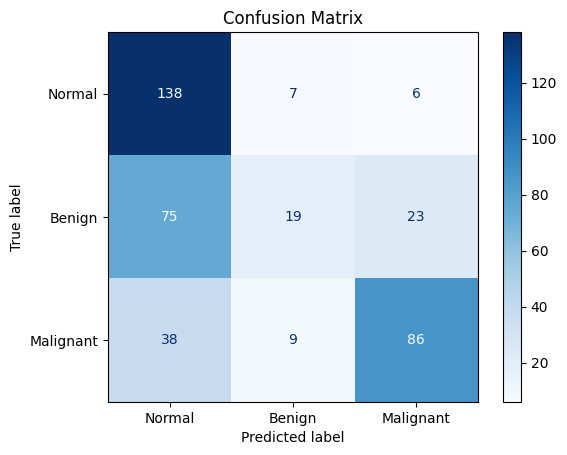

In [21]:

# ----------------------------
# Confusion Matrix
# ----------------------------
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_true, axis=1)
cm = confusion_matrix(y_true_classes, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Benign", "Malignant"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


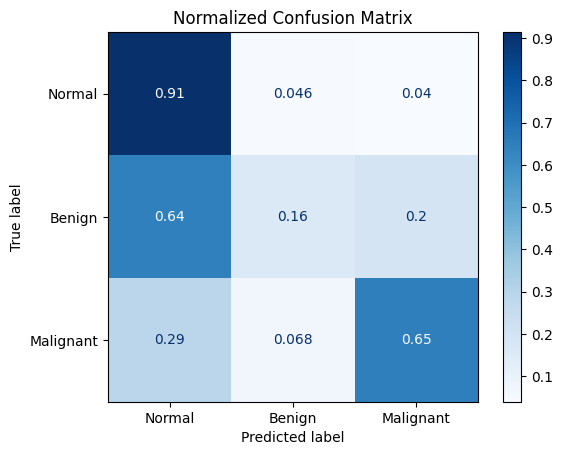

In [22]:
# filepath: /home/light/Documents/Perso/Internship/project/CDD_2_benchmark.ipynb
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(cm_norm, display_labels=["Normal", "Benign", "Malignant"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Normalized Confusion Matrix")
plt.show()

In [23]:
model.save("cdd_fusion_model_EfficientNetB0_2.h5")

In [24]:
def predict_class(image_path=None, tabular_array=None):
    # Prepare image
    if image_path is not None:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = img / 255.0
        img = tf.expand_dims(img, axis=0)  # Add batch dimension
    else:
        img = None

    # Prepare tabular data
    if tabular_array is not None:
        tab = np.array(tabular_array, dtype=np.float32)
        tab = np.expand_dims(tab, axis=0)  # Add batch dimension
    else:
        tab = None

    # Predict
    if img is not None and tab is not None:
        pred = model.predict({"raw_image": img, "tabular": tab})
    elif img is not None:
        pred = model.predict({"raw_image": img, "tabular": np.zeros((1, X_tab.shape[1]), dtype=np.float32)})
    elif tab is not None:
        pred = model.predict({"raw_image": np.zeros((1, *IMG_SIZE, 3), dtype=np.float32), "tabular": tab})
    else:
        raise ValueError("Provide at least image_path or tabular_array.")

    class_idx = np.argmax(pred, axis=1)[0]
    class_names = ["Normal", "Benign", "Malignant"]
    return class_names[class_idx], pred[0]

In [35]:
# Get a random row from the xlsx and retrieve the corresponding tabular array for the image

import random

# Pick a random row from the validation dataframe
random_row = val_df.sample(n=1).iloc[0]

# Get the image path and tabular array
image_path = random_row["filepath"]
tabular_array = random_row["tabular"]

# Predict using both image and tabular data
result = predict_class(image_path=image_path, tabular_array=tabular_array)
print("Random image + tabular prediction:", result)
print("Image path:", image_path)
result_image_only = predict_class(image_path=image_path)
print("Image only prediction:", result_image_only)
result_tabular_only = predict_class(tabular_array=tabular_array)
print("Tabular only prediction:", result_tabular_only)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Random image + tabular prediction: ('Malignant', array([0.02994489, 0.1361301 , 0.83392507], dtype=float32))
Image path: CDD-CESM/organized_images/malignant/P292_R_CM_MLO.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Image only prediction: ('Malignant', array([0.02994489, 0.1361301 , 0.83392507], dtype=float32))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Tabular only prediction: ('Normal', array([0.70084935, 0.22856312, 0.07058761], dtype=float32))
